<a href="https://colab.research.google.com/github/olyadiya/Intro_to_ML/blob/main/clustering_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Часть 1. K‑Means (обязательно)

1. Загрузите данные, удалите столбец `quality`, выполните **масштабирование** (StandardScaler).

In [1]:
!wget https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv

--2026-04-25 13:05:31--  https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84143 (82K) [text/plain]
Saving to: ‘wineqr.csv’

wineqr.csv          100%[===================>]  82.17K  --.-KB/s    in 0.02s   

2026-04-25 13:05:31 (5.26 MB/s) - ‘wineqr.csv’ saved [84143/84143]



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv('wineqr.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
X = df.drop(columns=['quality'])

In [5]:
# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

2. Для `K` от 2 до 10:
   - Обучите K‑Means
   - Вычислите WCSS и коэффициент силуэта

In [6]:
range_n_clusters = range(2, 11)
wcss = []
silhouette_scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    print(f"K={k}: WCSS={kmeans.inertia_:.1f}, Silhouette={sil:.3f}")

K=2: WCSS=14330.1, Silhouette=0.214
K=3: WCSS=12630.0, Silhouette=0.189
K=4: WCSS=11459.1, Silhouette=0.172
K=5: WCSS=10155.5, Silhouette=0.190
K=6: WCSS=9363.2, Silhouette=0.195
K=7: WCSS=8645.2, Silhouette=0.193
K=8: WCSS=8299.0, Silhouette=0.150
K=9: WCSS=7969.3, Silhouette=0.153
K=10: WCSS=7671.0, Silhouette=0.157


3. Постройте **два графика**: метод локтя (WCSS) и средний силуэт.

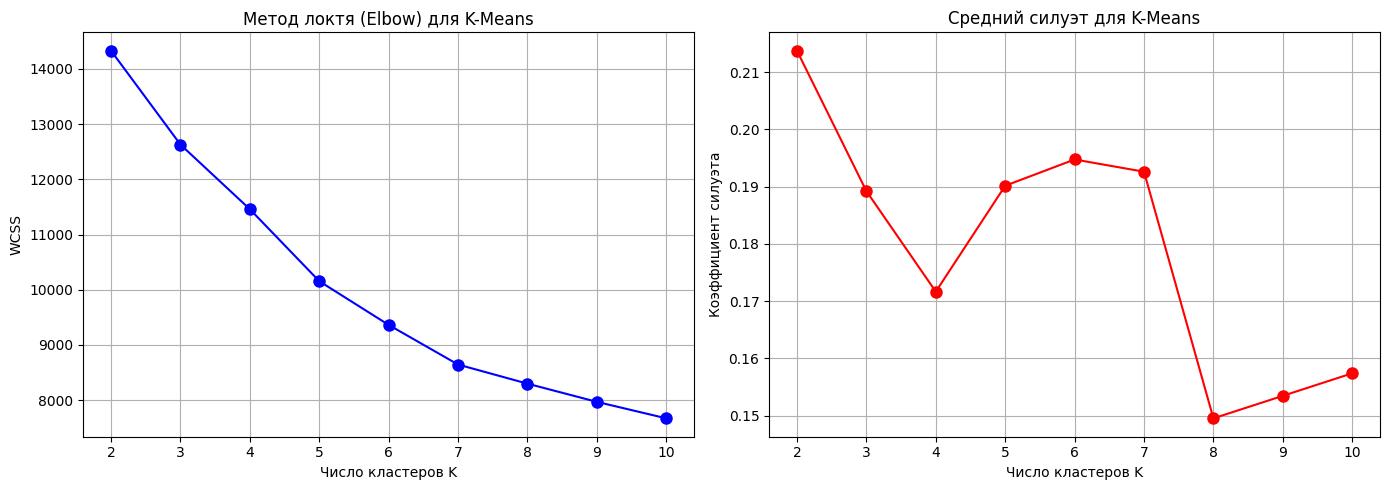

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range_n_clusters, wcss, 'bo-', markersize=8)
ax1.set_xlabel('Число кластеров K')
ax1.set_ylabel('WCSS')
ax1.set_title('Метод локтя (Elbow) для K-Means')
ax1.grid(True)

ax2.plot(range_n_clusters, silhouette_scores, 'ro-', markersize=8)
ax2.set_xlabel('Число кластеров K')
ax2.set_ylabel('Коэффициент силуэта')
ax2.set_title('Средний силуэт для K-Means')
ax2.grid(True)

plt.tight_layout()
plt.show()

4. Выберите оптимальное `K` по силуэту.

In [8]:
optimal_k = range_n_clusters[np.argmax(silhouette_scores)]
print(f"\nОптимальное число кластеров по силуэту: {optimal_k}")


Оптимальное число кластеров по силуэту: 2


5. Обучите финальную модель K‑Means с выбранным `K`.
6. С помощью PCA (2 компоненты) визуализируйте кластеры.
7. Выведите силуэт финальной модели.

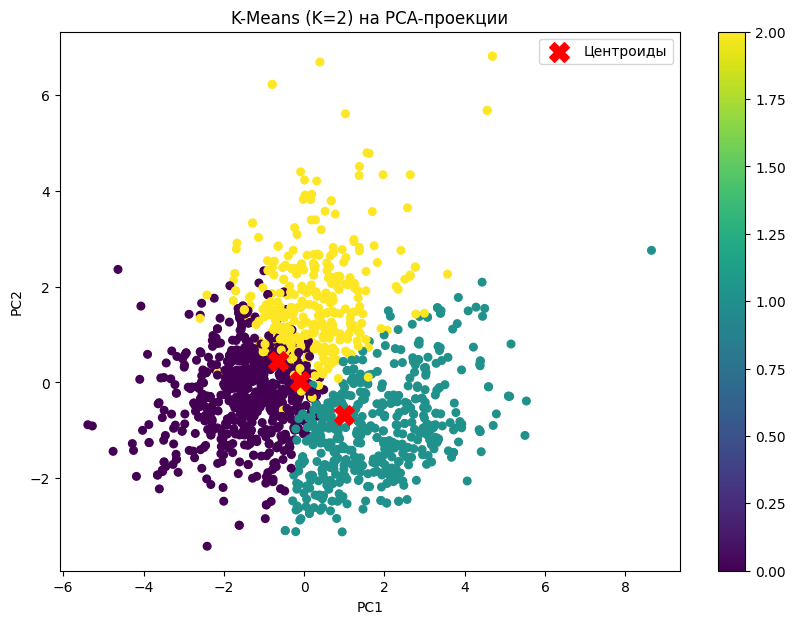

In [9]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=30)
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
            marker='X', c='red', s=200, label='Центроиды')
plt.title(f'K-Means (K={optimal_k}) на PCA-проекции')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.colorbar(scatter)
plt.show()

## Часть 2. DBSCAN
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

### Задания

1. Постройте **k‑distance graph** для `min_samples = 5, 10, 15`.  
   *Код можно взять из туториала или документации.*



In [15]:
#на этапе обучения выдывал ошибку cannot unpack non-iterable NoneType object, как я поняла - из-за чувсвтительности к масштабу, нашла вот такое решение:
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(X)

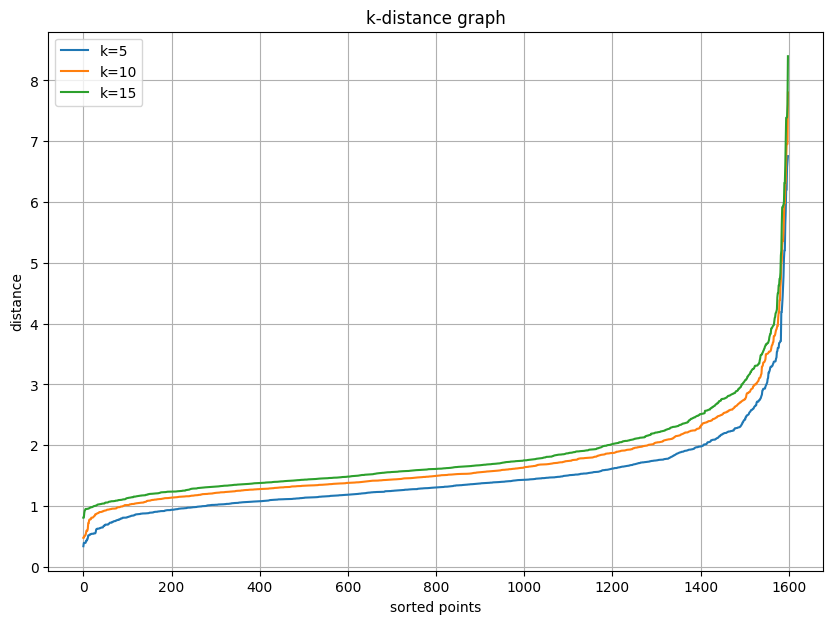

In [16]:
def plot_k_distance(X, k_list):
    plt.figure(figsize=(10, 7))
    for k in k_list:
        neigh = NearestNeighbors(n_neighbors=k)
        neigh.fit(X)
        distances, _ = neigh.kneighbors(X)
        k_distances = np.sort(distances[:, -1])
        plt.plot(k_distances, label=f'k={k}')
    plt.title("k-distance graph")
    plt.xlabel("sorted points")
    plt.ylabel("distance")
    plt.legend()
    plt.grid()
    plt.show()
plot_k_distance(X, [5, 10, 15])

2. Методом перебора (`eps` от 0.3 до 1.1 с шагом 0.1, `min_samples` = 5, 10, 15) найдите параметры, дающие **максимальный силуэт** (число кластеров ≥ 2, шум не более 80% данных).

In [17]:
best_score = -1
best_parameters = None
eps_values = np.arange(0.3, 1.2, 0.1)
min_samples_list = [5, 10, 15]
for eps in eps_values:
    for min_samples in min_samples_list:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X)
        unique_labels = set(labels)
        n_clusters = len(unique_labels - {-1})
        if n_clusters < 2:
            continue
        noise_ratio = np.sum(labels == -1) / len(labels)
        if noise_ratio > 0.8:
            continue
        try:
            score = silhouette_score(X, labels)
            if score > best_score:
                best_score = score
                best_parameters = (eps, min_samples)
        except:
            pass
print("best parameters:", best_parameters)
print("best silhouette:", best_score)

best parameters: (np.float64(1.1000000000000003), 10)
best silhouette: -0.22388308075627192


3. Обучите DBSCAN с лучшими параметрами.


In [18]:
best_eps, best_min_samples = best_parameters
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels = dbscan.fit_predict(X)

4. Визуализируйте результат через PCA (точки шума — отдельным цветом/меткой).

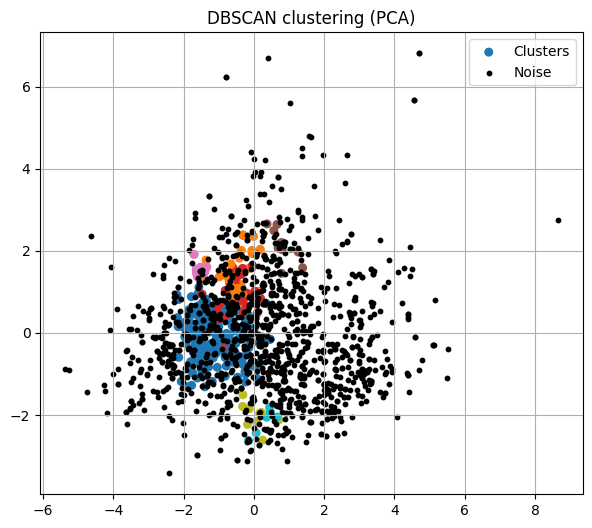

In [20]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(7, 6))
noise_mask = labels == -1
cluster_mask = labels != -1
plt.scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1], c=labels[cluster_mask], cmap='tab10', s=30, label='Clusters')
plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], c='black', s=10, label='Noise')
plt.title("DBSCAN clustering")
plt.legend()
plt.grid()
plt.show()

5. **Ответьте на вопросы (письменно):**
   - Почему для DBSCAN критически важно масштабировать данные?
  
Чтобы избежать неправильного распределения если один из признаков будет "сильно доминирующим"

   - Что будет при слишком маленьком `eps`? Слишком большом?

маленький - будет много шума;

большое - все объединится в один кластер.

   - Что означают точки с меткой `-1`?

Точки с меткой -1 — это шум. Это точки, которые не имеют достаточного числа соседей в радиусе eps, чтобы считаться частью какого-либо кластера

   - Чем DBSCAN принципиально отличается от K‑Means по форме кластеров?

DBSCAN не требует заранее задавать число кластеров и способен выделять шум, в отличие от K-Means, который всегда разбивает данные на заданное число кластеров. DBSCAN может выделять кластеры произвольной формы, а K-Means предполагает, что кластеры имеют сферическую форму.


## Часть 3. OPTICS (домашнее задание)

**Изучите документацию:**  
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.OPTICS.html

### Задания

1. Обучите OPTICS на тех же данных с параметрами:
   - `min_samples = 10`
   - `xi = 0.05`
   - `min_cluster_size = 0.05`

In [22]:
from sklearn.cluster import OPTICS


In [23]:
optics = OPTICS(
    min_samples=10,
    xi=0.05,
    min_cluster_size=0.05
)
labels = optics.fit_predict(X)



2. Выведите:
- количество найденных кластеров
- количество шумовых точек
- коэффициент силуэта

In [24]:
#число кластеров (без шума)
n_clusters = len(set(labels) - {-1})
#число шумовых точек
n_noise = np.sum(labels == -1)
#силуэт
if n_clusters >= 2:
    score = silhouette_score(X, labels)
else:
    score = None

print("сlusters:", n_clusters)
print("noise:", n_noise)
print("silhouette:", score)

сlusters: 1
noise: 0
silhouette: None


3. Постройте:
- визуализацию кластеров через PCA
- **reachability plot** (график достижимости)

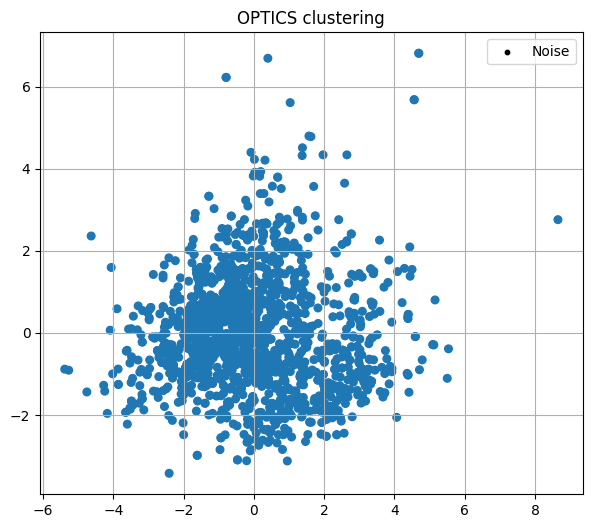

In [25]:
#pca
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(7, 6))
noise_mask = labels == -1
cluster_mask = labels != -1
plt.scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1], c=labels[cluster_mask], cmap='tab10', s=30)
plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], c='black', s=10, label='Noise')
plt.title("OPTICS clustering")
plt.legend()
plt.grid()
plt.show()

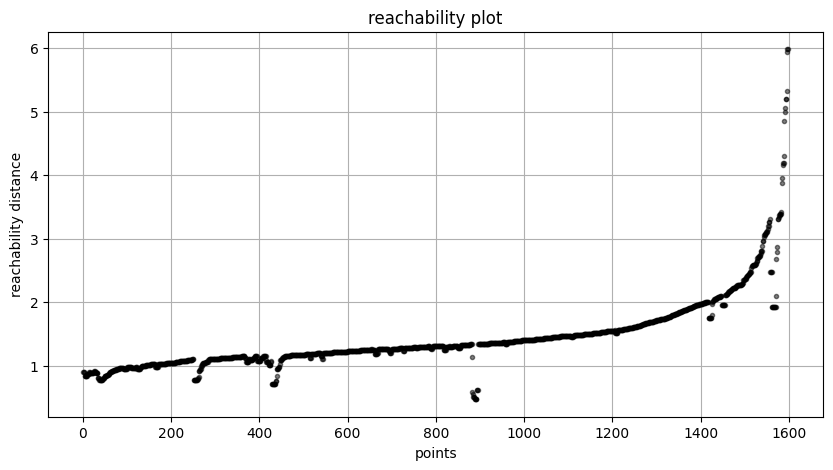

In [26]:
#reachibility plot
space = np.arange(len(X))
reachability = optics.reachability_[optics.ordering_]
labels_ordered = labels[optics.ordering_]
plt.figure(figsize=(10, 5))
plt.plot(space, reachability, 'k.', alpha=0.5)
plt.title("reachability plot")
plt.xlabel("points")
plt.ylabel("reachability distance")
plt.grid()
plt.show()

4. **Ответьте на вопросы (письменно, развёрнуто):**

- Чем OPTICS отличается от DBSCAN? Укажите **два ключевых отличия**.

DBSCAN работает с кластерами одной плотности, а OPTICS может выделять кластеры разной плотности.

DBSCAN сразу присваивает метки кластеров, OPTICS сначала строит reachability plot и извлекает кластеры из него.

- Что такое параметр xi (кси) и как он влияет на выделение кластеров?

Определяет минимальный наклон на reachability plot, который определяет границу кластера. (не знаю как красиво перевести, поэтому еще цитата из scikit "For example, an upwards point in the reachability plot is defined by the ratio from one point to its successor being at most 1-xi.")

- В каком случае OPTICS даст результат, существенно лучший, чем DBSCAN? Приведите пример.

Когда у кластеров разная плотность: OPTICS сможет выделить разные, а DBSCAN либо найдет один кластер, а все остальное уйдет в шум, либо из всех данных сделает один большой кластер.

- Сравните время работы DBSCAN и OPTICS на ваших данных (можно замерить через %timeit или time.time()).

DBSCAN: 0.10271954536437988

OPTICS: 6.28334903717041

DBSCAN быстрее

- Судя по визуализациям, какой алгоритм (K‑Means, DBSCAN, OPTICS) лучше разделил данные? Почему?

Лучше всех разделил данные К-Means - выделили несколько кластеров с центроидами;

Неплохо справился и DBSCAN, несмотря на то что выделено было также много шума, все равно видно разбинение на кластеры (скорее всего много нужно выбрать другое значение eps, чтобы снизить шум).

Хуже всего справился OPTICS - не выделил кластеры, скорее всего данные не подходят для такого типа кластеризации.

In [28]:
import time
# DBSCAN
start = time.time()
DBSCAN(eps=best_eps, min_samples=best_min_samples).fit(X)
db_time = time.time() - start
# OPTICS
start = time.time()
OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05).fit(X)
optics_time = time.time() - start

print("DBSCAN:", db_time)
print("OPTICS:", optics_time)

DBSCAN: 0.10271954536437988
OPTICS: 6.28334903717041
